# Decision Tree 🪾

The decision tree is a widely used model for classification and regression problems.

In scikit-learn, decision trees are implemented as **`DecisionTreeRegressor`** and **`DecisionTreeClassifier`**.  
Scikit-learn supports only **`pre-pruning`** (also known as early stopping) for decision trees.

A `decision tree` is a classification model that divides the space of independent variables by sequentially applying multiple rules. Since it can be used for both `classification` and `regression`, it is also called a `CART` (Classification And Regression Tree). This time, let's try REGRESSION analysis.


In [595]:
### import libs
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

%matplotlib inline
import numpy as np

In [596]:
# import warnings
# warnings.filterwarnings("ignore")

# 🩸 Diabetes Example

In [597]:
from sklearn.datasets import load_diabetes

diab = load_diabetes()
X_train, X_test, y_train, y_test = train_test_split(diab.data, diab.target)


In [598]:
tree = DecisionTreeClassifier(max_depth=50, random_state=0)
tree.fit(X_train, y_train)
print(tree.score(X_train, y_train))
print(tree.score(X_test, y_test))

# print("Accuracy on the training subset: {:.3f}".format(tree.score(X_train, y_train)))
# print("Accuracy on the test subset: {:.3f}".format(tree.score(X_test, y_test)))

1.0
0.018018018018018018


/Users/I751244/Desktop/soop/datascience/ds101/.dsenv/lib/python3.12/site-packages/sklearn/utils/multiclass.py:213: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  y_type = type_of_target(y, input_name="y")
/Users/I751244/Desktop/soop/datascience/ds101/.dsenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
/Users/I751244/Desktop/soop/datascience/ds101/.dsenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/U

why test score so low? how should we fix this

In [599]:
diab.target

array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
        69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
        68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
        87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
       259.,  53., 190., 142.,  75., 142., 155., 225.,  59., 104., 182.,
       128.,  52.,  37., 170., 170.,  61., 144.,  52., 128.,  71., 163.,
       150.,  97., 160., 178.,  48., 270., 202., 111.,  85.,  42., 170.,
       200., 252., 113., 143.,  51.,  52., 210.,  65., 141.,  55., 134.,
        42., 111.,  98., 164.,  48.,  96.,  90., 162., 150., 279.,  92.,
        83., 128., 102., 302., 198.,  95.,  53., 134., 144., 232.,  81.,
       104.,  59., 246., 297., 258., 229., 275., 281., 179., 200., 200.,
       173., 180.,  84., 121., 161.,  99., 109., 115., 268., 274., 158.,
       107.,  83., 103., 272.,  85., 280., 336., 281., 118., 317., 235.,
        60., 174., 259., 178., 128.,  96., 126., 28

### Let's use pandas qcut

In [600]:
pd.cut(diab.target, bins=4)

[(105.25, 185.5], (24.679, 105.25], (105.25, 185.5], (185.5, 265.75], (105.25, 185.5], ..., (105.25, 185.5], (24.679, 105.25], (105.25, 185.5], (185.5, 265.75], (24.679, 105.25]]
Length: 442
Categories (4, interval[float64, right]): [(24.679, 105.25] < (105.25, 185.5] < (185.5, 265.75] < (265.75, 346.0]]

In [601]:
import pandas as pd

bins = [24,106,186,266,346]

y_train_cats = pd.cut(y_train, bins, labels=[0, 1, 2, 3])
y_test_cats = pd.cut(y_test, bins, labels=[0, 1, 2, 3])

In [602]:
tree = DecisionTreeClassifier(max_depth=4, random_state=0)
tree.fit(X_train, y_train_cats)
print(tree.score(X_train, y_train_cats))
print(tree.score(X_test, y_test_cats))

0.6404833836858006
0.45045045045045046


### Or decision tree regressor

In [603]:
X_train, X_test, y_train, y_test = train_test_split(diab.data, diab.target, random_state=10)

tree = DecisionTreeRegressor(max_depth=4)
tree.fit(X_train, y_train)
print(tree.score(X_train, y_train))
print(tree.score(X_test, y_test))

0.5872992032891571
0.317039590260799


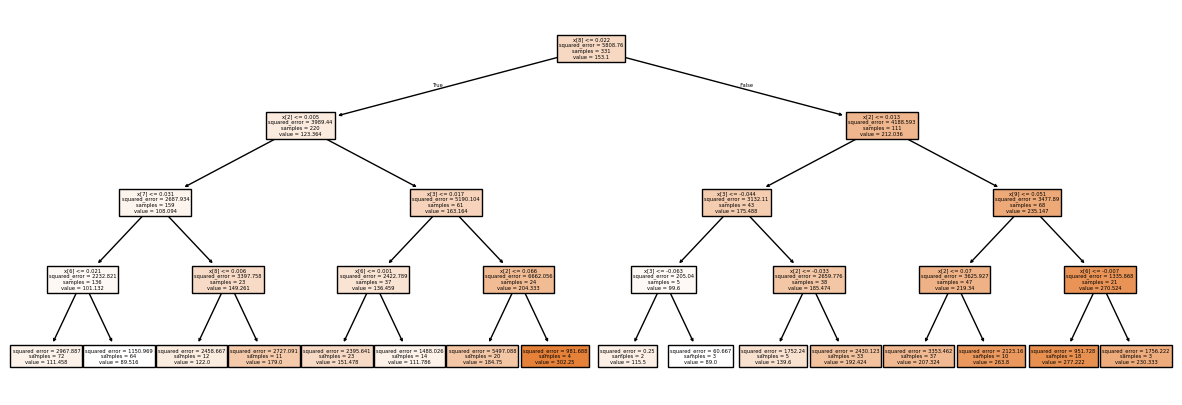

In [610]:
from sklearn.tree import plot_tree

plt.figure(figsize=(15, 5))
plot_tree(tree, filled=True)
plt.show()

# ∿ SIN Graph Example

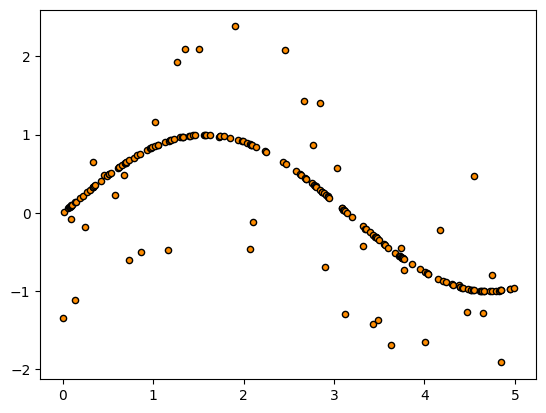

In [617]:
# random sample data for dt regression
rng = np.random.RandomState(1)
N = 200

X = np.sort(5 * rng.rand(N, 1), axis=0)
y = np.sin(X).flatten()
y[::5] += 3 * (0.5 - rng.rand(N//5))
plt.scatter(X, y, s=20, edgecolor="black", c="darkorange", label="data")
plt.show()

ValueError: Unknown label type: continuous. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.


In [618]:
# model = DecisionTreeClassifier(max_depth=3)
# model.fit(X, y)  

## Using pd.qcut

In [629]:
ycats = pd.qcut(y, 5, labels=list("qwert"))

clr = DecisionTreeClassifier(max_depth=10)
clr.fit(X, ycats)
print(f"Score: {clr.score(X, ycats)}")

Score: 0.995


## Using Tree Regressor

In [631]:
regtree1 = DecisionTreeRegressor(max_depth=10)
regtree1.fit(X, y)
print(f"Score: {regtree1.score(X, y)}")

Score: 0.965172486748376


In [632]:
regtree2 = DecisionTreeRegressor(max_depth=5)
regtree2.fit(X, y)
print(f"Score: {regtree2.score(X, y)}")

Score: 0.8576282630025912


In [636]:
regtree3 = DecisionTreeRegressor(max_depth=3)
regtree3.fit(X, y)
print(f"Score: {regtree3.score(X, y)}")

Score: 0.751919601917747


### plot tree regressor

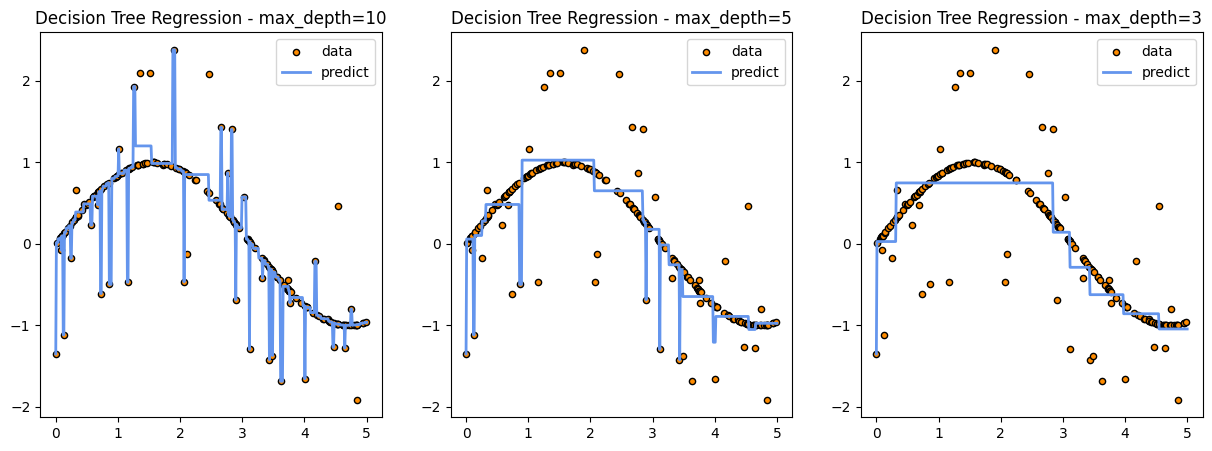

In [642]:
test_N = 500
X_test = np.linspace(0, 5.0, test_N)[:, np.newaxis]
y_hat1 = regtree1.predict(X_test)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.scatter(X, y, s=20, edgecolor="black", c="darkorange", label="data")
plt.plot(X_test, y_hat1, color="cornflowerblue", linewidth=2, label="predict")
plt.title("Decision Tree Regression - max_depth=10")
plt.legend()


plt.subplot(1,3,2)
y_hat2 = regtree2.predict(X_test)
plt.scatter(X, y, s=20, edgecolor="black", c="darkorange", label="data")


plt.plot(X_test, y_hat2, color="cornflowerblue", linewidth=2, label="predict")
plt.title("Decision Tree Regression - max_depth=5")
plt.legend()


plt.subplot(1, 3, 3)
y_hat3= regtree3.predict(X_test)
plt.scatter(X, y, s=20, edgecolor="black", c="darkorange", label="data")


plt.plot(X_test, y_hat3, color="cornflowerblue", linewidth=2, label="predict")
plt.title("Decision Tree Regression - max_depth=3")
plt.legend()
plt.show()

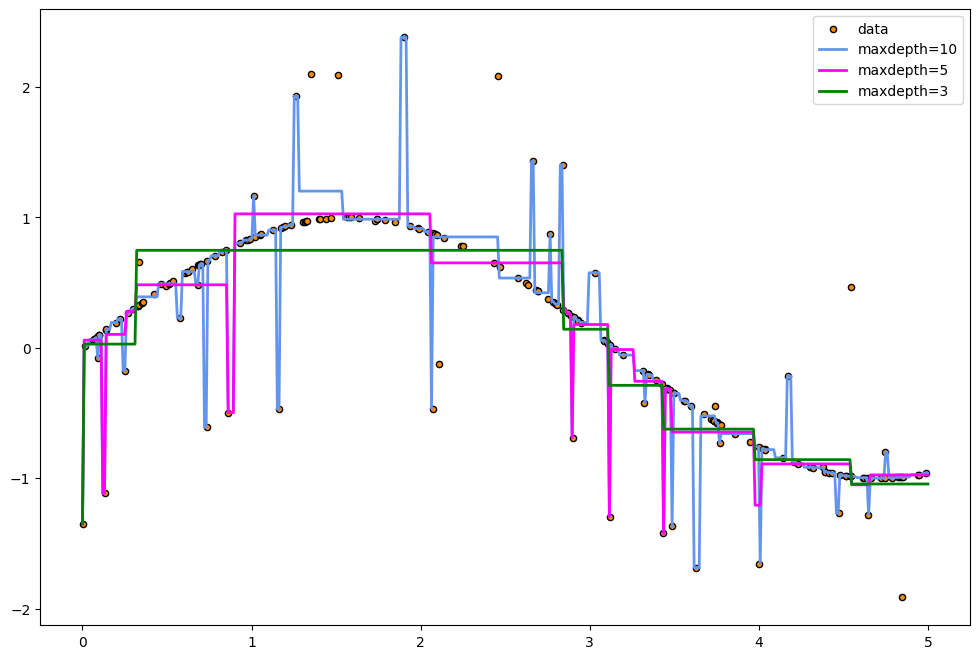

In [645]:
plt.figure(figsize=(12, 8))
plt.scatter(X, y, s=20, edgecolor="black", c="darkorange", label="data")
plt.plot(X_test, y_hat1, color="cornflowerblue", linewidth=2, label="maxdepth=10")
plt.plot(X_test, y_hat2, color="magenta", linewidth=2, label="maxdepth=5")
plt.plot(X_test, y_hat3, color="green", linewidth=2, label="maxdepth=3")
plt.legend()